In [185]:
import pandas as pd
import os
import numpy as np
import ast
import collections
from pygenomeviz import GenomeViz
import ast
import pysam
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update({
    "pdf.fonttype": 42,  
    "ps.fonttype": 42,   
    "svg.fonttype": "none"  
})

mpl.rcParams["font.family"] = "Arial"

In [186]:
#QC checked good AZFc regions
errDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/QC/LocationFiles/AZFc_QC_File.csv").drop(columns=['Unnamed: 0'])

In [187]:
myDF2=pd.read_csv("/LeeLab/HPRC/chromosomeY/Data/DAZ_Mappings/DAZNames_PSV.csv").set_index("Unnamed: 0")
myDF2['end']=[int(x.split("-")[1]) for x in myDF2.index]
myDF2['sample']=[x.split("_")[0] for x in myDF2['contig']]

In [188]:
colorDict={'DAZ1_EXON1':'pink',
    'DAZ1_EXON2-7-12':'lightblue',
            'DAZ1_EXON3-8-13':'black',
            'DAZ1_EXON4-9-14':'red',
            'DAZ1_EXON5-10-15':'green',
            'DAZ1_EXON6-11-16':'purple',
           'DAZ1_EXON17':'yellow',
            'DAZ1_EXON18':'yellow',
           'DAZ1_EXON19':'yellow',
           'DAZ1_EXON20-22':'yellow',
           'DAZ1_EXON21':'yellow',
           'DAZ1_EXON23':'yellow',
           'DAZ1_EXON24':'yellow',
           'DAZ1_EXON25':'yellow',
           'DAZ1_EXON26':'lime',
           'DAZ1_EXON27':'grey',
           'DAZ1_EXON28':'blue',   
}

In [189]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

In [190]:
from typing import List, Optional
from Bio import Phylo

def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [191]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [192]:
haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

In [193]:
for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

140


In [194]:
hgsvc = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_07162025.csv')
hprc = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HPRC_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_06162025.csv')
ceph = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/CEPH_chrYAmpliconicGene_Filtered_wLiftOffAnnotation_09092025.csv')


dazDFCEPH = ceph[ceph['geneName']=='DAZ1'].copy()
dazDFCEPH['Consortia']="CEPH"
dazDFCEPH['contigStart']=dazDFCEPH['contigStart'].astype(int)
dazDFCEPH['contigEnd']=dazDFCEPH['contigEnd'].astype(int)
dazDFCEPH.sort_values(by=['contig','contigStart'], inplace=True)

dazDFHGSVC = hgsvc[hgsvc['geneName']=='DAZ1'].copy()
dazDFHGSVC['Consortia']="HGSVC"
dazDFHGSVC['contigStart']=dazDFHGSVC['contigStart'].astype(int)
dazDFHGSVC['contigEnd']=dazDFHGSVC['contigEnd'].astype(int)
dazDFHGSVC.sort_values(by=['contig','contigStart'], inplace=True)

dazDFHPRC = hprc[hprc['geneName']=='DAZ1'].copy()
dazDFHPRC['Consortia']="HPRC"
dazDFHPRC['contigStart']=dazDFHPRC['contigStart'].astype(int)
dazDFHPRC['contigEnd']=dazDFHPRC['contigEnd'].astype(int)
dazDFHPRC.sort_values(by=['contig','contigStart'], inplace=True)

In [195]:
combinedDAZ0 = pd.concat([dazDFHPRC,dazDFHGSVC,dazDFCEPH])
combinedDAZ1 = combinedDAZ0[~combinedDAZ0['contig'].str.contains("random")].copy()
combinedDAZ = combinedDAZ1[combinedDAZ1['sampleName'].isin(set(errDF['sample']))].copy()

print(len(combinedDAZ1))
print(len(combinedDAZ))
combinedDAZ.reset_index(inplace=True)

505
382


## RepeatMasker

In [196]:
rmDict={}
directory="/LeeLab/HPRC/chromosomeY/Data/RepeatMasker/"
for file in os.listdir(directory):
    rmDict[file.split(".")[0]]=directory+file
print(len(rmDict))

146


In [197]:
repeatList=[]
for sample in set(combinedDAZ['sampleName']):

    rmDF = pd.read_csv(rmDict[sample], sep='\t')
    
    sampleDF = combinedDAZ[combinedDAZ['sampleName']==sample].copy()
    for row in sampleDF.index:
        contig = str(sampleDF.at[row,'contig'])
        start = int(sampleDF.at[row,'contigStart'])
        end = int(sampleDF.at[row,'contigEnd'])

        subRMDF = rmDF[(rmDF['query_match_start']>=start) & (rmDF['query_match_end']<=end) & (rmDF['query_name']==contig)].copy()
        subRMDF['sample']=sample
        repeatList.append(subRMDF)

rmCombined = pd.concat(repeatList)

In [198]:
contigSizes=[]
for row in combinedDAZ.index:
    exons = ast.literal_eval(str(combinedDAZ.at[row,'Exons']))
    contigSizes.append(exons[0][7].split("(")[1].split(")")[0])
combinedDAZ['ContigSizeRemaining']=contigSizes               

In [199]:
len(set(combinedDAZ['sampleName']))

100

In [200]:
dazExonDFDict={}
dazExonDFList=[]
for sample in phylogeneticOrder:
    print(sample)   
    tempDF = combinedDAZ[combinedDAZ['sampleName']==sample].copy()

    for contig in set(tempDF['contig']):

        tempDF2 = tempDF[tempDF['contig']==contig].copy()
        orderList =[]
        for row in tempDF2.index:

            name = str(tempDF2.at[row,'contig'])+":"+str(tempDF2.at[row,'contigStart'])+"-"+str(tempDF2.at[row,'contigEnd'])
            
            rnaBinding={'DAZ1_EXON2-7-12':0,
                    'DAZ1_EXON3-8-13':0,
                    'DAZ1_EXON4-9-14':0,
                    'DAZ1_EXON5-10-15':0,
                    'DAZ1_EXON6-11-16':0,
                   }
            
            for exon in ast.literal_eval(str(tempDF2.at[row,'Exons'])):
                if exon[9] in rnaBinding:
                    rnaBinding[exon[9]]+=1
                else:
                    continue

            minValue = min(rnaBinding, key=rnaBinding.get)
            orderList.append(rnaBinding[minValue])
            dazExonDFDict[name]={'RRMs':rnaBinding[minValue]}

        print(sample, contig, orderList)
        dazExonDFList.append([sample, contig, orderList])

HG02984
HG01890
HG01890 HG01890_chrY [1, 2, 1, 3]
HG02647
HG02666
HG02666 HG02666_chrY [3, 1, 1, 2]
HG02668
HG03225
HG03225 HG03225_chrY [3, 1, 1, 2]
NA19043
NA19384
HG005
HG005 HG005_chrY [3, 1]
NA18952
NA18952 NA18952_chrY [3, 1]
NA18983
NA18983 NA18983_chrY [1, 3]
HG02572
HG02572 HG02572_chrY [3, 1, 2, 1]
HG03248
HG03248 HG03248_chrY [3, 1, 2, 1]
HG03098
HG03050
NA19239
NA19239 NA19239_chrY [3, 1, 2, 1]
HG01074
HG01074 HG01074_chrY [3, 1, 2, 2]
HG01109
HG01109 HG01109_chrY [3, 1, 2, 2]
HG01106
NA19331
NA19331 NA19331_chrY [3, 1, 2, 1]
HG01252
HG01252 HG01252_chrY [3, 1, 1, 2]
HG01457
HG01457 HG01457_chrY [1, 3, 1, 2]
HG03065
HG03065 HG03065_chrY [1, 2, 1, 3, 1, 2]
HG02717
HG02717 HG02717_chrY [3, 1, 1, 2]
HG03471
HG03471 HG03471_chrY [1, 2, 1, 3]
HG02011
HG02011 HG02011_chrY [3, 1, 1, 2]
HG03371
HG03371 HG03371_chrY [3, 1, 1, 2]
HG02486
HG02965
HG02965 HG02965_chrY [3, 1, 1, 2]
HG03139
HG03139 HG03139_chrY [3, 1, 1, 2]
NA19443
NA19443 NA19443_chrY [3, 1, 1, 2]
NA19317
NA19317 NA1931

In [201]:
exondazDF = pd.DataFrame(data=dazExonDFList, columns=['sample','contig','exonList'])
#exondazDF.to_csv('/LeeLab/HPRC/chromosomeY/Data/HGSVC3_HPRC_CEPH_DAZ_RRM_CopyNumbers_Jan222026.csv')

In [202]:
letterExonDict={'17':'B', '18':'C','19':'D','20-22':'E','21':'F','23':'X','24':'Y','25':'Z', '17Diverged':'A'}

In [203]:
import ast
import pandas as pd

sizes={}
contigSizeInformation = {}
visualizeSamples = ()
genome_geneList = []
orientationDict = {'+': 1, 'C': -1}
gap = 5000 

for sample in phylogeneticOrder:

    if sample not in list(combinedDAZ['sampleName']):
        continue

    tempDF = combinedDAZ[combinedDAZ['sampleName'] == sample].copy()
    tempRMDF = rmCombined[rmCombined['sample'] == sample].copy()

    for contig_id in tempDF['contig'].unique():

        contigDAZ = tempDF[tempDF['contig'] == contig_id].copy()
        contigRM = tempRMDF[tempRMDF['query_name'] == contig_id].copy()

        newTempList = []
        RowCount = 1

        for row in contigDAZ.index:
            start = contigDAZ.at[row, 'contigStart']
            end = contigDAZ.at[row, 'contigEnd']
            orientation = orientationDict[contigDAZ.at[row, 'orientation']]

            exonList = ast.literal_eval(str(contigDAZ.at[row, 'Exons']))
            for exon in exonList:
                exonNumber = exon[9].split("EXON")[1]
                if exonNumber in letterExonDict:
                    if exonNumber == '17' and float(exon[1])>0.0:
                        label='A'
                    else:
                        label = letterExonDict[exonNumber]
                else:
                    if str(exon[1]) == '0.0':
                        label=''
                    else:
                        label = str(exon[1])
                newTempList.append([
                    exon[4],                
                    exon[5],            
                    exon[6],              
                    1,                   
                    label,                 
                    f'block_{RowCount}',     
                    colorDict[exon[9]],exon[9], exon[8]
                ])

            blockRM = contigRM[
                (contigRM['query_match_start'] >= start) &
                (contigRM['query_match_end']   <= end)
            ].copy()

            for rrow in blockRM.index:
                newTempList.append([
                    str(blockRM.at[rrow, 'query_name']),       
                    int(blockRM.at[rrow, 'query_match_start']),
                    int(blockRM.at[rrow, 'query_match_end']),
                    -1,
                    str(blockRM.at[rrow, 'repeat_class_family']),
                    f'block_{RowCount}',
                    blockRM.at[rrow, 'pct_sub'], 'Repeat', str(blockRM.at[rrow,'match_orientation'])
                ])

            RowCount += 1

        if not newTempList:
            continue

        newCombinedDFTemp = pd.DataFrame(data=newTempList).sort_values(by=[1])
        min_start = newCombinedDFTemp[1].min()
        newCombinedDFTemp['NewStart'] = newCombinedDFTemp[1] - (min_start - 1)
        newCombinedDFTemp['NewEnd']   = newCombinedDFTemp[2] - (min_start - 1)

        unique_blocks = set(newCombinedDFTemp[5])

        if len(unique_blocks) == 4:
            block2 = newCombinedDFTemp[newCombinedDFTemp[5] == 'block_2'].copy()
            block3 = newCombinedDFTemp[newCombinedDFTemp[5] == 'block_3'].copy()

            secondBlockEnd   = block2['NewEnd'].max()
            thirdBlockStart  = block3['NewStart'].min()

            desired_third_start = secondBlockEnd + gap
            shift34 = thirdBlockStart - desired_third_start

            blockGroup12 = newCombinedDFTemp[newCombinedDFTemp[5].isin(['block_1', 'block_2'])].copy()
            blockGroup34 = newCombinedDFTemp[newCombinedDFTemp[5].isin(['block_3', 'block_4'])].copy()

            blockGroup34['NewStart'] = blockGroup34['NewStart'] - shift34
            blockGroup34['NewEnd']   = blockGroup34['NewEnd']   - shift34

            newDF = pd.concat([blockGroup12, blockGroup34], ignore_index=True)

        elif len(unique_blocks) == 6:
            block2 = newCombinedDFTemp[newCombinedDFTemp[5] == 'block_2'].copy()
            block3 = newCombinedDFTemp[newCombinedDFTemp[5] == 'block_3'].copy()
            block4 = newCombinedDFTemp[newCombinedDFTemp[5] == 'block_4'].copy()

            blockGroup12 = newCombinedDFTemp[newCombinedDFTemp[5].isin(['block_1', 'block_2'])].copy()
            blockGroup34 = newCombinedDFTemp[newCombinedDFTemp[5].isin(['block_3', 'block_4'])].copy()
            blockGroup56 = newCombinedDFTemp[newCombinedDFTemp[5].isin(['block_5', 'block_6'])].copy()

            secondBlockEnd  = block2['NewEnd'].max()
            thirdBlockStart = block3['NewStart'].min()

            desired_third_start = secondBlockEnd + gap
            shift34 = thirdBlockStart - desired_third_start

            blockGroup34['NewStart'] = blockGroup34['NewStart'] - shift34
            blockGroup34['NewEnd']   = blockGroup34['NewEnd']   - shift34

            shifted_block4 = blockGroup34[blockGroup34[5] == 'block_4']
            shifted_block4_end = shifted_block4['NewEnd'].max()

            desired_fifth_start = shifted_block4_end + gap
            current_fifth_start = blockGroup56[blockGroup56[5] == 'block_5']['NewStart'].min()

            shift56 = current_fifth_start - desired_fifth_start

            blockGroup56['NewStart'] = blockGroup56['NewStart'] - shift56
            blockGroup56['NewEnd']   = blockGroup56['NewEnd']   - shift56

            newDF = pd.concat([blockGroup12, blockGroup34, blockGroup56], ignore_index=True)

        else:
            newDF = newCombinedDFTemp
            
        if len(unique_blocks) == 3 or 'random' in contig_id:
            continue
        else:
            sizes[f"{sample}|{contig_id}"]=max(newDF['NewEnd'])
            genome_geneList.append({
                "name": f"{sample}|{contig_id}",
                "df": newDF,
                'haplogroup':haplogroups[sample]
            })


In [204]:
test = genome_geneList[0]['df']
test['SIZE']=[y-x for x,y in zip(test['NewStart'], test['NewEnd'])]

## Find the gene patterns

In [205]:
goodSamplesDAZ = []
dazExonDFDict2 = dazExonDFDict.copy()

for sample in genome_geneList:
    contig = sample['name'].split("|")[1]
    
    if contig not in set(myDF2['contig']):
        print(contig, 'NOTHERE')
        continue

    goodSamplesDAZ.append(sample)

    goodrows = []
    testDF = sample['df'].copy()

    for row in testDF.index:
        if 'DAZ' in str(testDF.at[row,7]):
            goodrows.append(row)
        else:
            if (str(testDF.at[row,4]) == 'LINE/L1' and int(testDF.at[row,'NewEnd']) - int(testDF.at[row,'NewStart']) > 3000):
                goodrows.append(row)

    testDF2 = testDF.loc[goodrows].copy()
    psvDF = myDF2[myDF2['contig'] == contig].copy()

    for gene in psvDF.index:
        if 'random' in str(gene):
            continue

        geneStart = int(gene.split(":")[1].split("-")[0])
        geneEnd   = int(gene.split(":")[1].split("-")[1])

        testDF3 = testDF2[(testDF2[1] >= geneStart) & (testDF2[1] <= geneEnd)].copy()

        orientation = None
        for row in testDF3.index:
            if testDF3.at[row,7] == 'DAZ1_EXON1':
                orientation = testDF3.at[row,8]
                break
            else:
                continue
        if orientation is None:
            continue

        allPatterns = []
        patterns = []

        for row in testDF3.index:
            value = str(testDF3.at[row, 4])
            if value == "":
                continue

            if value == 'LINE/L1':
                if patterns:             
                    allPatterns.append(patterns)
                    patterns = []
            else:
                if value in letterExonDict.values():
                    patterns.append(value)

        if patterns:
            allPatterns.append(patterns)

        if orientation == '+':
            dazExonDFDict2[gene]['DAZExons'] = allPatterns
        elif orientation == '-' or orientation =='C':
            rev_patterns = [list(reversed(p)) for p in reversed(allPatterns)]
            dazExonDFDict2[gene]['DAZExons'] = rev_patterns
        else:
            print(gene)
            break
            continue


In [206]:
len(goodSamplesDAZ)

100

In [207]:
len(dazExonDFDict2)

382

In [208]:
goodGeneNames={}
dazExonDFDict3 = {}
for gene in dazExonDFDict2:
    if 'random' in gene:
        continue
    else:
        dazExonDFDict3[gene] = dazExonDFDict2[gene]

In [209]:
combinedDAZ['name']=[str(x)+":"+str(y)+"-"+str(z) for x,y,z in zip(combinedDAZ['contig'],combinedDAZ['contigStart'],combinedDAZ['contigEnd'])]

In [210]:
combinedDAZ2 = combinedDAZ.set_index("name").copy()

In [211]:
FinaldazExonDFDict3= dazExonDFDict3.copy()
for key in FinaldazExonDFDict3.keys():
    #FinaldazExonDFDict3[key]['PSV_ID']=combinedDAZ2.at[key,'MaxLength_Liftoff_ID']
    FinaldazExonDFDict3[key]['Sample']=combinedDAZ2.at[key,'sampleName']
    FinaldazExonDFDict3[key]['Contig']=combinedDAZ2.at[key,'contig']
    FinaldazExonDFDict3[key]['Exons']=combinedDAZ2.at[key,'Exons']

In [212]:
for key in FinaldazExonDFDict3.keys():
    FinaldazExonDFDict3[key]['Pre-LINE_Exons']  = ''.join(FinaldazExonDFDict3[key]['DAZExons'][0])
    FinaldazExonDFDict3[key]['Post-LINE_Exons'] = ''.join(FinaldazExonDFDict3[key]['DAZExons'][1])

In [215]:
suppdf = pd.DataFrame(FinaldazExonDFDict3).T.drop(columns=['DAZExons'])

In [216]:
errDF=pd.read_csv("/LeeLab/HPRC/chromosomeY/QC/LocationFiles/AZFc_QC_File.csv").drop(columns=['Unnamed: 0'])

In [217]:
goodSamples = set(errDF['sample'])

In [218]:
dazAnnotDict={}
nameDict={}
directory='/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/CombinedFiles/'
for file in os.listdir(directory):
    if file == '.DS_Store':
        continue

    sample = file.split("_")[0]
    if sample in goodSamples:
        tempDF = pd.read_csv(directory+file)
        tempDF2 = tempDF[(tempDF['RM_Amplicon_Caller']=='CALLED') & (tempDF['RM_Amplicon_gene'].str.contains("DAZ"))].copy()
        dazAnnotDict[file.split("_")[0]]= len(tempDF2)
        for name, name2 in zip(tempDF2['RM_Amplicon_Coordinates'], tempDF2['RM_Amplicon_gene']):
            nameDict[name.split("(")[0]]=name2

In [220]:
for sample in dazAnnotDict:
    if dazAnnotDict[sample] == len(suppdf[suppdf['Sample']==sample]):
        continue
    else:
        #sample, combined file, this file
        print(sample, dazAnnotDict[sample], len(suppdf[suppdf['Sample']==sample]))

HG01099 4 2


In [224]:
nameDict

{'NA18952_chrY:24079474-24153912': 'DAZ4',
 'NA18952_chrY:24174438-24234297': 'DAZ3',
 'HG00290_chrY:24379528-24449192': 'DAZ1',
 'HG00290_chrY:24469717-24539145': 'DAZ2',
 'HG01358_chrY:23679778-23749435': 'DAZ1',
 'HG01358_chrY:23769960-23841782': 'DAZ2',
 'HG01358_chrY:25314029-25389522': 'DAZ4',
 'HG01358_chrY:25410048-25469910': 'DAZ3',
 'HG02135_chrY:24091740-24166179': 'DAZ4',
 'HG02135_chrY:24186706-24241809': 'DAZ3',
 'NA18608_chrY:24395294-24445646': 'DAZ2',
 'NA18608_chrY:24466171-24533464': 'DAZ2',
 'NA18608_chrY:26005176-26053133': 'DAZ1',
 'NA18608_chrY:26073658-26135933': 'DAZ2',
 'HG005_chrY:24417916-24494733': 'DAZ4',
 'HG005_chrY:24515260-24575123': 'DAZ3/DAZ4',
 'HG03732_chrY:24178450-24226418': 'DAZ2',
 'HG03732_chrY:24246943-24328519': 'DAZ1',
 'HG03732_chrY:25800213-25850551': 'DAZ3',
 'HG03732_chrY:25871077-25929899': 'DAZ4',
 'HG02391_chrY:23589067-23658727': 'DAZ1',
 'HG02391_chrY:23679252-23751066': 'DAZ2',
 'HG02391_chrY:25223133-25293873': 'DAZ4',
 'HG02391_

In [225]:
suppdf['PSV_ID']=[nameDict[x] for x in suppdf.index]

In [228]:
#suppdf.to_csv("/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/DAZ_Overview.csv")

In [25]:
PSVExonPatterns={x:{'RRMs':{}, 'BlockA':{}, 'BlockB':{}} for x in set(myDF2['MaxCount'])}
for daz in PSVExonPatterns.keys():
    dazGenes = list(myDF2[myDF2['MaxCount']==daz].index)

    for gene in dazGenes:
        if 'random' in gene:
            continue
        else:
            RRMs = dazExonDFDict3[gene]['RRMs']

            if RRMs == 0 or RRMs ==4:
                continue
            else:
                if 'DAZExons' in dazExonDFDict3[gene].keys() and len(dazExonDFDict3[gene]['DAZExons'])==2:
                    goodGeneNames[gene]=1
                    if RRMs in PSVExonPatterns[daz]['RRMs']:
                        PSVExonPatterns[daz]['RRMs'][RRMs]+=1
                    else:
                        PSVExonPatterns[daz]['RRMs'][RRMs]=1
    
                        
                    count=0
                    for block in dazExonDFDict3[gene]['DAZExons']:
                        if str(block) == 'None':
                            continue
                        else:
                            myString = ''.join(block)
                            if count == 0:
                                if myString == 'ab':
                                    print(dazExonDFDict3[gene])
                                    print(gene)
                                    
                                if myString in PSVExonPatterns[daz]['BlockA']:
                                    PSVExonPatterns[daz]['BlockA'][myString]+=1
                                else:
                                    PSVExonPatterns[daz]['BlockA'][myString]=1
    
                                count+=1
    
                            else:
                                
                                if myString in PSVExonPatterns[daz]['BlockB']:
                                    PSVExonPatterns[daz]['BlockB'][myString]+=1
                                else:
                                    PSVExonPatterns[daz]['BlockB'][myString]=1

In [26]:
PSVExonPatternsDetailed={x:{'RRMs':{1:{'BlockA':{}, 'BlockB':{}},2:{'BlockA':{}, 'BlockB':{}},3:{'BlockA':{}, 'BlockB':{}}}} for x in set(myDF2['MaxCount'])}

for daz in PSVExonPatternsDetailed.keys():
    dazGenes = list(myDF2[myDF2['MaxCount']==daz].index)

    for gene in dazGenes:
        if 'random' in gene:
            continue
        else:
            RRMs = dazExonDFDict3[gene]['RRMs']

            if RRMs == 0 or RRMs ==4:
                continue
            else:
                
                if 'DAZExons' in dazExonDFDict3[gene].keys() and len(dazExonDFDict3[gene]['DAZExons'])==2:
                    
                    count=0
                    for block in dazExonDFDict3[gene]['DAZExons']:
                        if str(block) == 'None':
                            continue
                        else:
                            
                            myString = ''.join(block) 
                            if count == 0:
                                    
                                if myString in PSVExonPatternsDetailed[daz]['RRMs'][RRMs]['BlockA']:
                                    PSVExonPatternsDetailed[daz]['RRMs'][RRMs]['BlockA'][myString]+=1
                                else:
                                    PSVExonPatternsDetailed[daz]['RRMs'][RRMs]['BlockA'][myString]=1
    
                                count+=1
    
                            else:
                                
                                if myString in PSVExonPatternsDetailed[daz]['RRMs'][RRMs]['BlockB']:
                                    PSVExonPatternsDetailed[daz]['RRMs'][RRMs]['BlockB'][myString]+=1
                                else:
                                    PSVExonPatternsDetailed[daz]['RRMs'][RRMs]['BlockB'][myString]=1

In [27]:
PSVExonPatternsDetailed2={x:{} for x in PSVExonPatternsDetailed.keys()}
for key in PSVExonPatternsDetailed.keys():
    PSVExonPatternsDetailed2[key]['RRMs']={}
    for number in PSVExonPatternsDetailed[key]['RRMs']:
        if len(PSVExonPatternsDetailed[key]['RRMs'][number]['BlockA'])==0:
            continue
        else:
            PSVExonPatternsDetailed2[key]['RRMs'][number]={'BlockA':PSVExonPatternsDetailed[key]['RRMs'][number]['BlockA'], 'BlockB':PSVExonPatternsDetailed[key]['RRMs'][number]['BlockB']}

In [28]:
rows = []

for gene, gene_data in PSVExonPatternsDetailed2.items():
    rrm_dict = gene_data.get("RRMs", {})
    for rrm, blocks in rrm_dict.items():
        for family, motif_dict in blocks.items():  # family = "BlockA"/"BlockB"
            for motif, count in motif_dict.items():
                rows.append({
                    "Gene": gene,
                    "RRM": rrm,
                    "Family": family,
                    "Motif": motif,
                    "Count": count
                })

df2 = pd.DataFrame(rows)

In [29]:
rrm_totals = (
    df2[(df2['Family']=='BlockA')].groupby(["Gene", "RRM"], as_index=False)["Count"]
      .sum()
)

rrm_totals["Family"] = "RRMs"

rrm_totals["Motif"] = rrm_totals["RRM"].astype(str)

df_all = pd.concat([df2, rrm_totals], ignore_index=True)

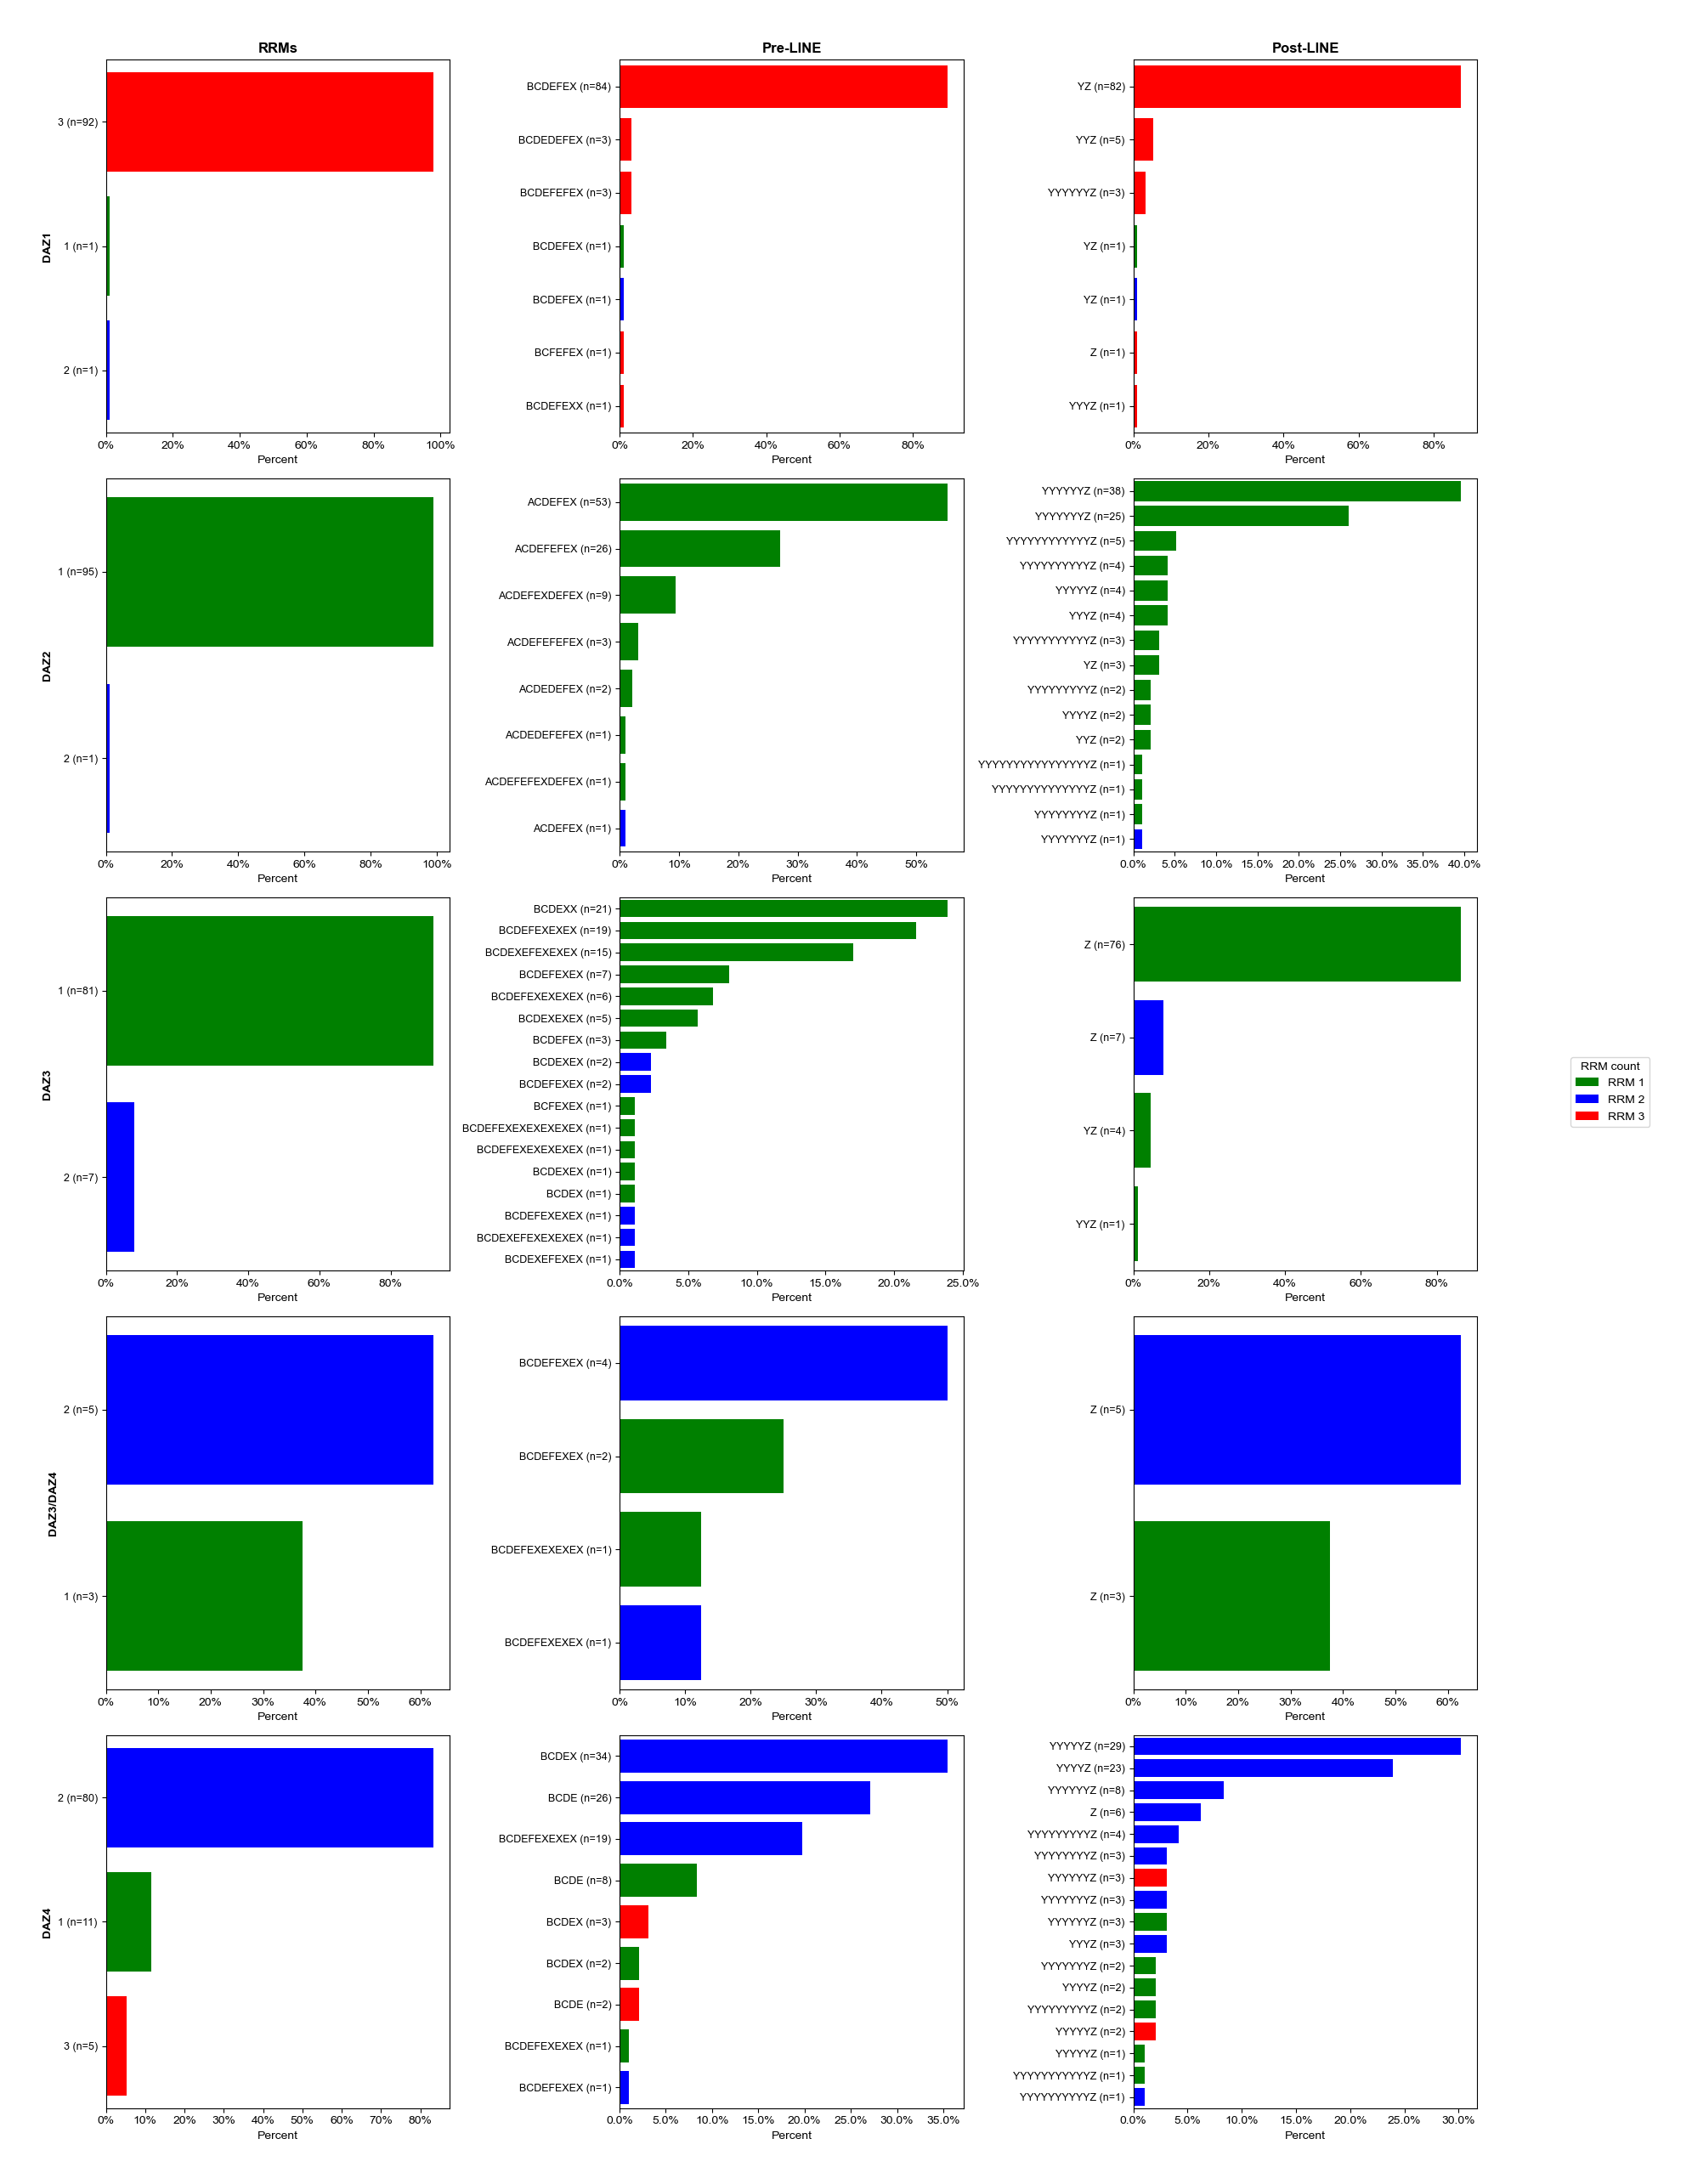

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Patch

df_plot = df_all.copy()

gene_order = ["DAZ1", "DAZ2", "DAZ3", "DAZ3/DAZ4", "DAZ4"]
gene_order = [g for g in gene_order if g in df_plot["Gene"].unique()]

desired_families = ["RRMs", "BlockA", "BlockB"]
family_order = [f for f in desired_families if f in df_plot["Family"].unique()]

family_title_map = {
    "RRMs": "RRMs",
    "BlockA": "Pre-LINE",
    "BlockB": "Post-LINE",
}

n_rows = len(gene_order)
n_cols = len(family_order)


fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7 * n_cols, 5 * n_rows),
    sharex=False, sharey=False
)

if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = axes[:, np.newaxis]

rrm_color = {
    1: "green",
    2: "blue",
    3: "red",
    4: "orange",
}


for i, gene in enumerate(gene_order):
    for j, fam in enumerate(family_order):
        ax = axes[i, j]

        tmp = df_plot[(df_plot["Gene"] == gene) & (df_plot["Family"] == fam)].copy()
        if tmp.empty:
            ax.axis("off")
            continue

        tmp["Percent"] = tmp["Count"] / tmp["Count"].sum() * 100
        tmp["MotifLabel"] = tmp["Motif"].astype(str) + " (n=" + tmp["Count"].astype(str) + ")"
        tmp = tmp.sort_values("Percent", ascending=False).reset_index(drop=True)

        tmp["MotifKey"] = tmp["MotifLabel"] + "___" + tmp.index.astype(str)

        sns.barplot(
            data=tmp,
            x="Percent",
            y="MotifKey",
            order=tmp["MotifKey"].tolist(),
            orient="h",
            ax=ax,
            errorbar=None
        )

        for k, bar in enumerate(ax.patches):
            rrm = tmp.loc[k, "RRM"]
            bar.set_facecolor(rrm_color.get(rrm, "grey"))

        ax.set_yticks(np.arange(len(tmp)))
        ax.set_yticklabels(tmp["MotifLabel"])
        ax.tick_params(axis="y", labelsize=9)  # was 7

        ax.tick_params(axis="x", labelsize=10)

        if i == 0:
            ax.set_title(family_title_map.get(fam, fam), fontweight="bold")

        if j == 0:
            ax.set_ylabel(gene, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Percent")
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))


fig.subplots_adjust(right=0.82)

handles = [
    Patch(facecolor=c, label=f"RRM {r}")
    for r, c in sorted(rrm_color.items())
    if r in set(df_plot["RRM"].unique())
]
fig.legend(
    handles=handles,
    title="RRM count",
    loc="center left",
    bbox_to_anchor=(0.86, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.savefig("/AllDAZMotifs_RRMColored_Jan222026.jpeg",
            format='jpeg', dpi=300, bbox_inches='tight')
plt.savefig("/AllDAZMotifs_RRMColored_Jan222026.pdf",
            format='pdf', bbox_inches='tight')
plt.show()


In [31]:
import json
file_path = "/LeeLab/HPRC/chromosomeY/Data/PSV_Hits_PerDAZGene_GoodGenes.json"
#with open(file_path, "w") as json_file:
#    json.dump(goodGeneNames, json_file)

In [32]:
rows = []
for gene, gene_dict in PSVExonPatterns.items():
    for family, motifs in gene_dict.items():
        for motif, count in motifs.items():
            rows.append({
                "Gene": gene,
                "Family": family,
                "Motif": motif,
                "Count": count,
                "MotifLen": len(motif) if isinstance(motif, str) else motif
            })

df = pd.DataFrame(rows)
df

,Gene,Family,Motif,Count,MotifLen
0,DAZ3/DAZ4,RRMs,2,5,2
1,DAZ3/DAZ4,RRMs,1,3,1
2,DAZ3/DAZ4,BlockA,BCDEFEXEX,6,9
3,DAZ3/DAZ4,BlockA,BCDEFEXEXEXEX,1,13
4,DAZ3/DAZ4,BlockA,BCDEFEXEXEX,1,11
...,...,...,...,...,...
73,DAZ3,BlockA,BCDEXEFEXEXEXEX,1,15
74,DAZ3,BlockA,BCDEXEFEXEX,1,11
75,DAZ3,BlockB,Z,83,1
76,DAZ3,BlockB,YZ,4,2
